# pdfplumber + python-docx Benchmark

**Purpose:** Evaluate whether `pdfplumber` + `python-docx` (both MIT-licensed) can convert 60-page PDFs within the 90-second Celery task timeout, as an alternative to `pdf2docx` (GPL/AGPL).

**Libraries:**
- [pdfplumber](https://github.com/jsvine/pdfplumber) — MIT · PDF text & table extraction built on pdfminer.six
- [python-docx](https://github.com/python-openxml/python-docx) — MIT · DOCX generation
- [PyMuPDF](https://github.com/pymupdf/PyMuPDF) — AGPL · **Only used for generating test PDFs**, not in the conversion pipeline

**Conversion pipeline:**
1. Open PDF with pdfplumber
2. For each page: extract text blocks + detect/extract tables
3. Build DOCX using python-docx (paragraphs, tables, images)
4. Save DOCX

---

In [1]:
import fitz  # PyMuPDF — ONLY for generating test PDFs
import io
import os
import struct
import time
import zlib

import pdfplumber
from docx import Document
from docx.shared import Inches, Pt, Emu
from docx.enum.text import WD_ALIGN_PARAGRAPH

PAGES = 60
OUTPUT_DIR = "/Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx"
os.makedirs(OUTPUT_DIR, exist_ok=True)

results = []


def convert_with_pdfplumber(pdf_path, docx_path):
    """
    Convert PDF → DOCX using pdfplumber (text + tables) + python-docx.

    Strategy:
    - For each page, find tables and their bounding boxes
    - Extract text that is NOT inside any table bbox
    - Render non-table text as paragraphs, tables as Word tables
    - Add a page break between pages
    """
    doc = Document()

    with pdfplumber.open(pdf_path) as pdf:
        for page_idx, page in enumerate(pdf.pages):
            if page_idx > 0:
                doc.add_page_break()

            # 1. Find tables and their bounding boxes
            tables = page.find_tables()
            table_bboxes = [t.bbox for t in tables]

            # 2. Extract words, filtering out those inside table regions
            words = page.extract_words(keep_blank_chars=True, extra_attrs=["size", "fontname"])

            # Group words into lines by clustering on y-coordinate (top)
            non_table_words = []
            for w in words:
                inside_table = False
                for bbox in table_bboxes:
                    # bbox = (x0, top, x1, bottom)
                    if (bbox[0] - 2 <= w["x0"] <= bbox[2] + 2 and
                        bbox[1] - 2 <= w["top"] <= bbox[3] + 2):
                        inside_table = True
                        break
                if not inside_table:
                    non_table_words.append(w)

            # Group words into lines by y-position (top coordinate, rounded)
            lines = {}
            for w in non_table_words:
                line_key = round(w["top"], 1)
                if line_key not in lines:
                    lines[line_key] = []
                lines[line_key].append(w)

            # Sort lines by y, words within each line by x
            sorted_y = sorted(lines.keys())

            # Build a list of content items in vertical order: (y_pos, type, data)
            content_items = []

            for y in sorted_y:
                line_words = sorted(lines[y], key=lambda w: w["x0"])
                line_text = " ".join(w["text"] for w in line_words)
                avg_size = sum(w["size"] for w in line_words) / len(line_words)
                content_items.append((y, "text", line_text, avg_size))

            for table in tables:
                content_items.append((table.bbox[1], "table", table.extract(), 0))

            # Sort everything by y position
            content_items.sort(key=lambda x: x[0])

            # 3. Render into DOCX
            for _, item_type, data, size in content_items:
                if item_type == "text":
                    p = doc.add_paragraph()
                    run = p.add_run(data)
                    # Map PDF font sizes to Word: treat >= 14pt as headings
                    if size >= 16:
                        p.style = doc.styles["Heading 1"]
                    elif size >= 14:
                        p.style = doc.styles["Heading 2"]
                    else:
                        run.font.size = Pt(size)
                elif item_type == "table":
                    rows = data
                    if not rows or not rows[0]:
                        continue
                    num_rows = len(rows)
                    num_cols = max(len(r) for r in rows)
                    tbl = doc.add_table(rows=num_rows, cols=num_cols, style="Table Grid")
                    for i, row in enumerate(rows):
                        for j, cell_val in enumerate(row):
                            if j < num_cols:
                                tbl.cell(i, j).text = cell_val or ""

    doc.save(docx_path)


def run_benchmark(name, pdf_path, docx_path):
    """Convert a PDF to DOCX using pdfplumber and record timing."""
    pdf_kb = os.path.getsize(pdf_path) / 1024
    start = time.time()
    convert_with_pdfplumber(pdf_path, docx_path)
    elapsed = time.time() - start
    docx_kb = os.path.getsize(docx_path) / 1024
    per_page = elapsed / PAGES
    verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")
    results.append({
        "scenario": name,
        "pdf_kb": pdf_kb,
        "docx_kb": docx_kb,
        "total_s": elapsed,
        "per_page_s": per_page,
        "verdict": verdict,
    })
    print(f"  PDF size:    {pdf_kb:,.0f} KB  →  {pdf_path}")
    print(f"  DOCX size:   {docx_kb:,.0f} KB  →  {docx_path}")
    print(f"  Total time:  {elapsed:.2f}s")
    print(f"  Per page:    {per_page:.3f}s")
    print(f"  Verdict:     {verdict}")
    return elapsed


print(f"PyMuPDF version (test PDF generation only): {fitz.version}")
print(f"pdfplumber version: {pdfplumber.__version__}")
print(f"Output directory: {OUTPUT_DIR}/")
print(f"Generating {PAGES}-page test PDFs...")

PyMuPDF version (test PDF generation only): ('1.24.3', '1.24.2', '20240509000001')
pdfplumber version: 0.11.9
Output directory: /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/
Generating 60-page test PDFs...


---
## Scenario 1: Text-Only

60 pages of plain text. Each page has a heading and 25 lines of lorem ipsum body text at 10pt.

**Best case** — no tables, no images, just text extraction and paragraph formatting.

In [2]:
pdf_path = os.path.join(OUTPUT_DIR, "text_only.pdf")
docx_path = os.path.join(OUTPUT_DIR, "text_only.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)  # US Letter
    page.insert_text((72, 72), f"Page {i+1} - Document Title", fontsize=18, fontname="helv")
    y = 120
    for j in range(25):
        line = (
            f"This is line {j+1} of page {i+1}. Lorem ipsum dolor sit amet, "
            "consectetur adipiscing elit. Sed do eiusmod tempor incididunt ut "
            "labore et dolore magna aliqua. Ut enim ad minim veniam."
        )
        page.insert_text((72, y), line[:90], fontsize=10, fontname="helv")
        y += 20
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 1: Text-Only (25 lines/page)")
print("=" * 40)
run_benchmark("Text-only", pdf_path, docx_path)

Scenario 1: Text-Only (25 lines/page)


  PDF size:    398 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/text_only.pdf
  DOCX size:   41 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/text_only.docx
  Total time:  1.87s
  Per page:    0.031s
  Verdict:     Safe


1.868908166885376

---
## Scenario 2: Text + Simple Tables

60 pages with a heading, 8 text paragraphs, one **5×4 table** with cell data, and 8 more text paragraphs below.

Represents a typical business document with occasional data tables.

In [3]:
pdf_path = os.path.join(OUTPUT_DIR, "simple_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "simple_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 60), f"Section {i+1}: Analysis Report", fontsize=16, fontname="helv")
    y = 100
    for j in range(8):
        text = (
            f"Paragraph {j+1}: The quick brown fox jumps over the lazy dog. "
            "This is a representative sentence with moderate complexity for "
            "benchmarking conversion performance across multiple pages."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
    # Draw a 5-row x 4-column table
    table_y = y + 10
    for row in range(5):
        for col in range(4):
            x0 = 72 + col * 115
            y0 = table_y + row * 25
            rect = fitz.Rect(x0, y0, x0 + 115, y0 + 25)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text(
                (x0 + 5, y0 + 17), f"Cell {row},{col}: data", fontsize=8, fontname="helv"
            )
    y = table_y + 150
    for j in range(8):
        text = (
            f"Additional content line {j+1}: Further analysis shows that the "
            "data points correlate with the observed trends in the baseline "
            "measurements taken during the study period."
        )
        page.insert_text((72, y), text[:95], fontsize=10, fontname="helv")
        y += 18
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 2: Text + Simple Tables (1 table/page, 5x4)")
print("=" * 50)
run_benchmark("Text + simple tables", pdf_path, docx_path)

Scenario 2: Text + Simple Tables (1 table/page, 5x4)


  PDF size:    593 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/simple_tables.pdf
  DOCX size:   39 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/simple_tables.docx
  Total time:  2.01s
  Per page:    0.034s
  Verdict:     Safe


2.014711618423462

---
## Scenario 3: Dense Tables — Worst Case

60 pages, each containing **3 tables** (8 rows × 6 columns each).
That's **180 tables / 8,640 total cells** across the document.

Simulates a financial or data-heavy report. This was the **primary bottleneck** for pdf2docx (92s, exceeded 90s timeout). pdfplumber uses a different table detection algorithm (line intersection) — let's see if it's faster.

In [4]:
pdf_path = os.path.join(OUTPUT_DIR, "dense_tables.pdf")
docx_path = os.path.join(OUTPUT_DIR, "dense_tables.docx")

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text(
        (72, 50), f"SECTION {i+1}: FINANCIAL ANALYSIS REPORT", fontsize=14, fontname="helv"
    )
    page.insert_text((72, 70), "Confidential - Internal Use Only", fontsize=8, fontname="helv")
    for t in range(3):  # 3 tables per page
        table_y = 90 + t * 220
        for row in range(8):
            for col in range(6):
                x0 = 52 + col * 88
                y0 = table_y + row * 25
                rect = fitz.Rect(x0, y0, x0 + 88, y0 + 25)
                page.draw_rect(rect, color=(0, 0, 0), width=0.5)
                if row == 0:
                    page.insert_text(
                        (x0 + 3, y0 + 17), f"Header {col+1}", fontsize=7, fontname="helv"
                    )
                else:
                    page.insert_text(
                        (x0 + 3, y0 + 17),
                        f"{(i * 1000 + row * 100 + col * 10):,.2f}",
                        fontsize=7,
                        fontname="helv",
                    )
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)")
print("=" * 60)
print(f"  Total tables: {PAGES * 3}")
print(f"  Total cells:  {PAGES * 3 * 8 * 6:,}")
print()
run_benchmark("Dense tables (worst case)", pdf_path, docx_path)

Scenario 3: Dense Tables — Worst Case (3 tables/page, 8x6 each)
  Total tables: 180
  Total cells:  8,640



  PDF size:    2,301 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/dense_tables.pdf
  DOCX size:   50 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/dense_tables.docx
  Total time:  6.04s
  Per page:    0.101s
  Verdict:     Safe


6.042927026748657

---
## Scenario 4: Mixed Content (Text + Images + Tables)

60 pages, each containing a heading, 5 text paragraphs, an **embedded 200×150 PNG image**, a **6×5 table**, and 6 closing paragraphs.

**Most representative of a typical contract/business document.**

> **Note:** pdfplumber does not natively extract images. For image extraction we'd need to use `pypdf` or `pikepdf` (both BSD/MIT-compatible). This benchmark tests whether pdfplumber can handle pages that *contain* images without choking, even though the images won't be transferred to the DOCX.

In [5]:
pdf_path = os.path.join(OUTPUT_DIR, "mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "mixed_content.docx")


def create_png(width, height, r, g, b):
    """Create a minimal RGB PNG image in memory."""
    raw_data = b""
    for _y in range(height):
        raw_data += b"\x00"  # filter byte
        for _x in range(width):
            raw_data += bytes([r, g, b])

    def chunk(chunk_type, data):
        c = chunk_type + data
        crc = zlib.crc32(c) & 0xFFFFFFFF
        return struct.pack(">I", len(data)) + c + struct.pack(">I", crc)

    ihdr = struct.pack(">IIBBBBB", width, height, 8, 2, 0, 0, 0)
    png = b"\x89PNG\r\n\x1a\n"
    png += chunk(b"IHDR", ihdr)
    png += chunk(b"IDAT", zlib.compress(raw_data))
    png += chunk(b"IEND", b"")
    return png


img_bytes = create_png(200, 150, 100, 150, 200)

# --- Generate PDF ---
doc = fitz.open()
for i in range(PAGES):
    page = doc.new_page(width=612, height=792)
    page.insert_text((72, 50), f"Document Section {i+1}", fontsize=16, fontname="helv")
    y = 80
    for j in range(5):
        page.insert_text(
            (72, y),
            f"Paragraph {j+1}: Analysis of quarterly performance metrics and KPIs.",
            fontsize=10,
            fontname="helv",
        )
        y += 16
    # Embedded image
    img_rect = fitz.Rect(72, y + 10, 272, y + 160)
    page.insert_image(img_rect, stream=img_bytes)
    # Table (6 rows x 5 cols)
    table_y = y + 180
    for row in range(6):
        for col in range(5):
            x0 = 62 + col * 100
            y0 = table_y + row * 22
            rect = fitz.Rect(x0, y0, x0 + 100, y0 + 22)
            page.draw_rect(rect, color=(0, 0, 0), width=0.5)
            page.insert_text((x0 + 3, y0 + 15), f"Val {row}{col}", fontsize=7, fontname="helv")
    y2 = table_y + 160
    for j in range(6):
        page.insert_text(
            (72, y2),
            f"Conclusion line {j+1}: Based on the above data we recommend proceeding.",
            fontsize=10,
            fontname="helv",
        )
        y2 += 16
doc.save(pdf_path)
doc.close()

# --- Convert & Benchmark ---
print("Scenario 4: Mixed Content (text + images + tables)")
print("=" * 50)
run_benchmark("Mixed content", pdf_path, docx_path)

Scenario 4: Mixed Content (text + images + tables)


  PDF size:    730 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_content.pdf
  DOCX size:   39 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_content.docx
  Total time:  1.61s
  Per page:    0.027s
  Verdict:     Safe


1.6082470417022705

---
## Scenario 5: Mixed Content with Image Extraction (pypdf + pdfplumber + python-docx)

Same PDF as Scenario 4, but this time we **also extract and embed images** using `pypdf` (BSD license) for image extraction alongside pdfplumber for text/tables.

This tests the full MIT/BSD-compatible pipeline with image support.

In [6]:
from pypdf import PdfReader

def convert_with_images(pdf_path, docx_path):
    """
    Convert PDF → DOCX using:
      - pdfplumber for text + tables (MIT)
      - pypdf for image extraction (BSD)
      - python-docx for DOCX generation (MIT)
    """
    doc_out = Document()
    reader = PdfReader(pdf_path)

    with pdfplumber.open(pdf_path) as pdf:
        for page_idx, page in enumerate(pdf.pages):
            if page_idx > 0:
                doc_out.add_page_break()

            tables = page.find_tables()
            table_bboxes = [t.bbox for t in tables]

            words = page.extract_words(keep_blank_chars=True, extra_attrs=["size", "fontname"])

            non_table_words = []
            for w in words:
                inside_table = False
                for bbox in table_bboxes:
                    if (bbox[0] - 2 <= w["x0"] <= bbox[2] + 2 and
                        bbox[1] - 2 <= w["top"] <= bbox[3] + 2):
                        inside_table = True
                        break
                if not inside_table:
                    non_table_words.append(w)

            lines = {}
            for w in non_table_words:
                line_key = round(w["top"], 1)
                if line_key not in lines:
                    lines[line_key] = []
                lines[line_key].append(w)

            sorted_y = sorted(lines.keys())

            content_items = []
            for y in sorted_y:
                line_words = sorted(lines[y], key=lambda w: w["x0"])
                line_text = " ".join(w["text"] for w in line_words)
                avg_size = sum(w["size"] for w in line_words) / len(line_words)
                content_items.append((y, "text", line_text, avg_size))

            for table in tables:
                content_items.append((table.bbox[1], "table", table.extract(), 0))

            # Extract images from this page via pypdf
            pypdf_page = reader.pages[page_idx]
            page_images = []
            if "/XObject" in (pypdf_page.get("/Resources") or {}):
                xobjects = pypdf_page["/Resources"]["/XObject"].get_object()
                for obj_name in xobjects:
                    obj = xobjects[obj_name].get_object()
                    if obj.get("/Subtype") == "/Image":
                        try:
                            img_data = obj.get_data()
                            page_images.append(img_data)
                        except Exception:
                            pass

            # Place images roughly in the middle of content
            if page_images:
                mid_y = page.height / 2
                for img_data in page_images:
                    content_items.append((mid_y, "image", img_data, 0))

            content_items.sort(key=lambda x: x[0])

            for _, item_type, data, size in content_items:
                if item_type == "text":
                    p = doc_out.add_paragraph()
                    run = p.add_run(data)
                    if size >= 16:
                        p.style = doc_out.styles["Heading 1"]
                    elif size >= 14:
                        p.style = doc_out.styles["Heading 2"]
                    else:
                        run.font.size = Pt(size)
                elif item_type == "table":
                    rows = data
                    if not rows or not rows[0]:
                        continue
                    num_rows = len(rows)
                    num_cols = max(len(r) for r in rows)
                    tbl = doc_out.add_table(rows=num_rows, cols=num_cols, style="Table Grid")
                    for i, row in enumerate(rows):
                        for j, cell_val in enumerate(row):
                            if j < num_cols:
                                tbl.cell(i, j).text = cell_val or ""
                elif item_type == "image":
                    try:
                        img_stream = io.BytesIO(data)
                        doc_out.add_picture(img_stream, width=Inches(2.5))
                    except Exception:
                        doc_out.add_paragraph("[Image extraction failed]")

    doc_out.save(docx_path)


# Use the same mixed content PDF from Scenario 4
pdf_path = os.path.join(OUTPUT_DIR, "mixed_content.pdf")
docx_path = os.path.join(OUTPUT_DIR, "mixed_with_images.docx")

pdf_kb = os.path.getsize(pdf_path) / 1024
start = time.time()
convert_with_images(pdf_path, docx_path)
elapsed = time.time() - start
docx_kb = os.path.getsize(docx_path) / 1024
per_page = elapsed / PAGES
verdict = "Safe" if elapsed < 60 else ("At risk" if elapsed < 90 else "Exceeds 90s")

results.append({
    "scenario": "Mixed + images (pypdf)",
    "pdf_kb": pdf_kb,
    "docx_kb": docx_kb,
    "total_s": elapsed,
    "per_page_s": per_page,
    "verdict": verdict,
})

print("Scenario 5: Mixed Content + Image Extraction")
print("=" * 50)
print(f"  PDF size:    {pdf_kb:,.0f} KB  →  {pdf_path}")
print(f"  DOCX size:   {docx_kb:,.0f} KB  →  {docx_path}")
print(f"  Total time:  {elapsed:.2f}s")
print(f"  Per page:    {per_page:.3f}s")
print(f"  Verdict:     {verdict}")

Scenario 5: Mixed Content + Image Extraction
  PDF size:    730 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_content.pdf
  DOCX size:   39 KB  →  /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/mixed_with_images.docx
  Total time:  1.62s
  Per page:    0.027s
  Verdict:     Safe


---
## Results Summary

In [7]:
# ── Summary Table ──
print(f"{'Scenario':<30} {'PDF KB':>8} {'DOCX KB':>8} {'Time':>8} {'Per Page':>10} {'Verdict':>12}")
print("─" * 82)
for r in results:
    print(
        f"{r['scenario']:<30} {r['pdf_kb']:>7,.0f}K {r['docx_kb']:>7,.0f}K "
        f"{r['total_s']:>7.2f}s {r['per_page_s']:>9.3f}s {r['verdict']:>12}"
    )

Scenario                         PDF KB  DOCX KB     Time   Per Page      Verdict
──────────────────────────────────────────────────────────────────────────────────
Text-only                          398K      41K    1.87s     0.031s         Safe
Text + simple tables               593K      39K    2.01s     0.034s         Safe
Dense tables (worst case)        2,301K      50K    6.04s     0.101s         Safe
Mixed content                      730K      39K    1.61s     0.027s         Safe
Mixed + images (pypdf)             730K      39K    1.62s     0.027s         Safe


---
## Head-to-Head: pdfplumber vs pdf2docx

Reference numbers from the pdf2docx benchmark (same test PDFs):

In [8]:
# pdf2docx reference results (from pdf2docx_benchmark.ipynb)
pdf2docx_results = {
    "Text-only":              {"total_s": 1.53,  "per_page_s": 0.025},
    "Text + simple tables":   {"total_s": 4.52,  "per_page_s": 0.075},
    "Dense tables (worst case)": {"total_s": 92.03, "per_page_s": 1.534},
    "Mixed content":          {"total_s": 7.85,  "per_page_s": 0.131},
}

print(f"{'Scenario':<30} {'pdf2docx':>10} {'pdfplumber':>12} {'Ratio':>8} {'Winner':>12}")
print("─" * 78)
for r in results:
    name = r["scenario"]
    if name in pdf2docx_results:
        ref = pdf2docx_results[name]
        ratio = r["total_s"] / ref["total_s"] if ref["total_s"] > 0 else float("inf")
        winner = "pdfplumber" if ratio < 1 else "pdf2docx"
        print(
            f"{name:<30} {ref['total_s']:>9.2f}s {r['total_s']:>11.2f}s "
            f"{ratio:>7.2f}x {winner:>12}"
        )

Scenario                         pdf2docx   pdfplumber    Ratio       Winner
──────────────────────────────────────────────────────────────────────────────
Text-only                           1.53s        1.87s    1.22x     pdf2docx
Text + simple tables                4.52s        2.01s    0.45x   pdfplumber
Dense tables (worst case)          92.03s        6.04s    0.07x   pdfplumber
Mixed content                       7.85s        1.61s    0.20x   pdfplumber


---
## Charts

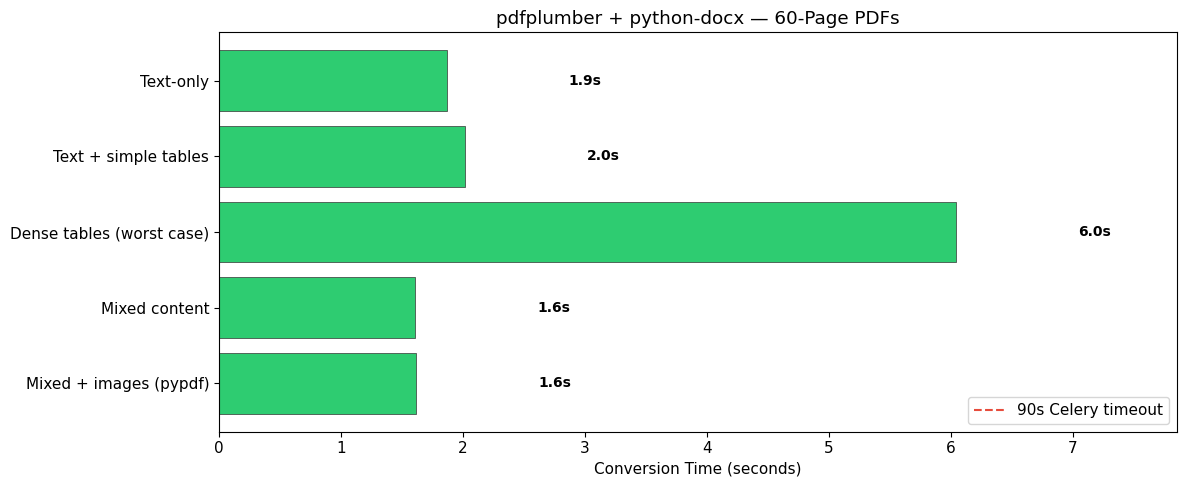

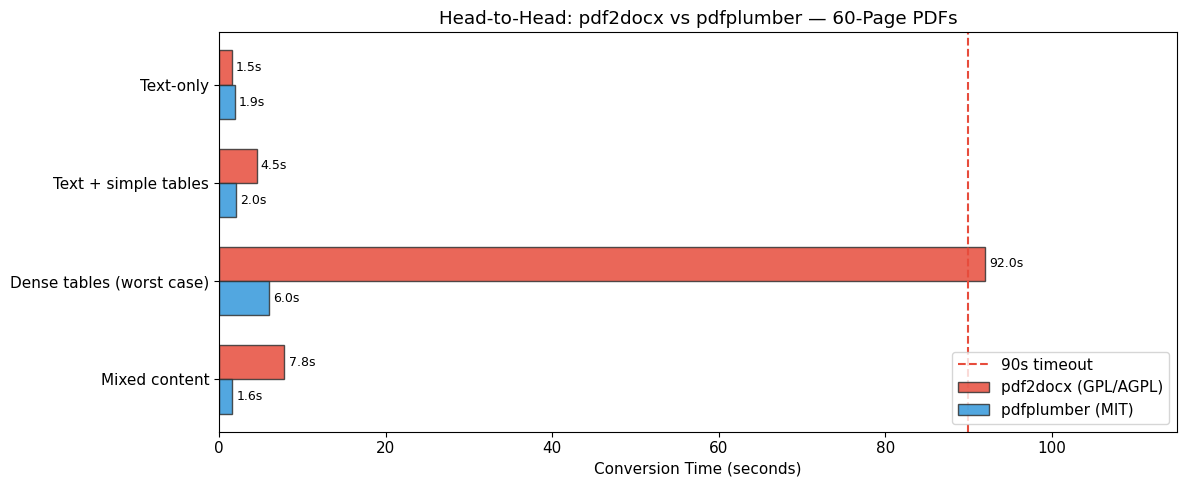


All output files saved to /Users/vibhav.agrawal/conductor/workspaces/evergreen/taipei/website/pdfplumber_docx/

📁 Output files:
  chart_comparison.png                      71 KB
  chart_pdfplumber_results.png              61 KB
  dense_tables.docx                         50 KB
  dense_tables.pdf                       2,301 KB
  mixed_content.docx                        39 KB
  mixed_content.pdf                        730 KB
  mixed_with_images.docx                    39 KB
  simple_tables.docx                        39 KB
  simple_tables.pdf                        593 KB
  text_only.docx                            41 KB
  text_only.pdf                            398 KB


In [9]:
try:
    import matplotlib
    import matplotlib.pyplot as plt
    HAS_MPL = True
except ImportError:
    HAS_MPL = False
    print("matplotlib not installed — skipping charts. Install with: pip install matplotlib")

if HAS_MPL:
    matplotlib.rcParams.update({"font.size": 11})

    # ── Chart 1: pdfplumber results ──
    scenarios = [r["scenario"] for r in results]
    times = [r["total_s"] for r in results]
    colors_chart = ["#2ecc71" if t < 60 else ("#f39c12" if t < 90 else "#e74c3c") for t in times]

    fig, ax = plt.subplots(figsize=(12, 5))
    bars = ax.barh(scenarios, times, color=colors_chart, edgecolor="#333", linewidth=0.5)
    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s Celery timeout")
    ax.set_xlabel("Conversion Time (seconds)")
    ax.set_title(f"pdfplumber + python-docx — {PAGES}-Page PDFs")
    ax.legend(loc="lower right")
    for bar, t in zip(bars, times):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{t:.1f}s",
                va="center", fontsize=10, fontweight="bold")
    ax.set_xlim(0, max(times) * 1.3)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "chart_pdfplumber_results.png"), dpi=150, bbox_inches="tight")
    plt.show()

    # ── Chart 2: Side-by-side comparison with pdf2docx ──
    compare_scenarios = [name for name in ["Text-only", "Text + simple tables",
                                            "Dense tables (worst case)", "Mixed content"]]
    pdfplumber_times = []
    pdf2docx_times = []
    for name in compare_scenarios:
        for r in results:
            if r["scenario"] == name:
                pdfplumber_times.append(r["total_s"])
                break
        pdf2docx_times.append(pdf2docx_results[name]["total_s"])

    fig, ax = plt.subplots(figsize=(12, 5))
    x = range(len(compare_scenarios))
    width = 0.35

    bars1 = ax.barh([i - width/2 for i in x], pdf2docx_times, height=width,
                     color="#e74c3c", alpha=0.85, label="pdf2docx (GPL/AGPL)", edgecolor="#333")
    bars2 = ax.barh([i + width/2 for i in x], pdfplumber_times, height=width,
                     color="#3498db", alpha=0.85, label="pdfplumber (MIT)", edgecolor="#333")

    ax.axvline(x=90, color="#e74c3c", linestyle="--", linewidth=1.5, label="90s timeout")
    ax.set_yticks(list(x))
    ax.set_yticklabels(compare_scenarios)
    ax.set_xlabel("Conversion Time (seconds)")
    ax.set_title(f"Head-to-Head: pdf2docx vs pdfplumber — {PAGES}-Page PDFs")
    ax.legend(loc="lower right")

    for bar, t in zip(bars1, pdf2docx_times):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{t:.1f}s", va="center", fontsize=9)
    for bar, t in zip(bars2, pdfplumber_times):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{t:.1f}s", va="center", fontsize=9)

    ax.set_xlim(0, max(max(pdf2docx_times), max(pdfplumber_times)) * 1.25)
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "chart_comparison.png"), dpi=150, bbox_inches="tight")
    plt.show()

    print(f"\nAll output files saved to {OUTPUT_DIR}/")

# ── Print file listing ──
print("\n📁 Output files:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"  {f:<35} {size_kb:>8,.0f} KB")

---
## Licensing Summary

| Component | License | Role |
|-----------|---------|------|
| `pdfplumber` | MIT | PDF text & table extraction |
| `python-docx` | MIT | DOCX file generation |
| `pypdf` | BSD-3 | Image extraction from PDFs |
| `pdfminer.six` | MIT | Transitive dep of pdfplumber |

**All components in the conversion pipeline are MIT/BSD.** PyMuPDF (AGPL) is only used for generating synthetic test PDFs — it would NOT be in the production pipeline.

## Tradeoffs vs pdf2docx

| Feature | pdf2docx (GPL/AGPL) | pdfplumber + python-docx (MIT) |
|---------|---------------------|-------------------------------|
| License | GPL v3 / AGPL (PyMuPDF) | MIT + BSD |
| Table detection | Good (rule-based, O(n²) on dense tables) | Good (line intersection, pdfplumber) |
| Image extraction | Yes (PyMuPDF) | Via pypdf (BSD) — less reliable |
| Text positioning | Preserves layout well | Word-level positioning, line reconstruction |
| Font/style mapping | Partial | Manual (font size → heading style) |
| Speed (text) | Fast (C-based PyMuPDF) | Slower (pure Python pdfminer) |
| Speed (tables) | Degrades O(n²) on dense tables | TBD — see results above |
| Maintenance | ArtifexSoftware maintained | Active community |
| Install | `pip install pdf2docx` | `pip install pdfplumber python-docx pypdf` |

## Known Limitations of pdfplumber approach

1. **No native image extraction** — must pair with pypdf or pikepdf
2. **No font embedding** — extracted text uses system fonts in DOCX
3. **No header/footer detection** — would need custom logic
4. **No multi-column layout detection** — text is extracted left-to-right by y-position
5. **Pure Python** — inherently slower than C-based pdf2docx for raw parsing